<a href="https://colab.research.google.com/github/MukeshMoharana/Head-and-Neck-Tumor-Segmentation-Using-HITL_MIRS-NET/blob/main/MIRS_NET_Stage2_ClickRefinement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!pip install -q monai
import monai

print(monai.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 49.1 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


1.5.2


In [5]:
import os

IMAGE_DIR = "/content/drive/MyDrive/Datasets/medical datasets/Full_Dataset_Cropped/home/256_cropped/imagesTr"
LABEL_DIR = "/content/drive/MyDrive/Datasets/medical datasets/Full_Dataset_Cropped/home/256_cropped/labelsTr"

images = sorted(os.listdir(IMAGE_DIR))
labels = set(os.listdir(LABEL_DIR))

matched = 0
missing = []

for img in images:

    if not img.endswith(".nii.gz"):
        continue

    case_id = img.replace("_0000.nii.gz", "")

    label1 = case_id + ".nii"
    label2 = case_id + ".nii.gz"

    if label1 in labels or label2 in labels:
        matched += 1
    else:
        missing.append(img)

print(f"Matched: {matched}")
print(f"Missing: {len(missing)}")

if missing:
    print("\nMissing cases:")
    for m in missing:
        print(m)

Matched: 213
Missing: 0


In [6]:
import os
import nibabel as nib
import numpy as np

IMAGE_DIR = "/content/drive/MyDrive/Datasets/medical datasets/Full_Dataset_Cropped/home/256_cropped/imagesTr"
LABEL_DIR = "/content/drive/MyDrive/Datasets/medical datasets/Full_Dataset_Cropped/home/256_cropped/labelsTr"

# First image
sample = sorted(os.listdir(IMAGE_DIR))[0]

# Build corresponding mask path
case_id = sample.replace("_0000.nii.gz", "")

mask_path = None

if os.path.exists(os.path.join(LABEL_DIR, case_id + ".nii")):
    mask_path = os.path.join(LABEL_DIR, case_id + ".nii")

elif os.path.exists(os.path.join(LABEL_DIR, case_id + ".nii.gz")):
    mask_path = os.path.join(LABEL_DIR, case_id + ".nii.gz")

# Load image
img_path = os.path.join(IMAGE_DIR, sample)

img = nib.load(img_path)

print("IMAGE FILE:", sample)
print("Shape:", img.shape)
print("Spacing:", img.header.get_zooms())

# Load mask
mask = nib.load(mask_path)

print("\nMASK FILE:", os.path.basename(mask_path))
print("Mask Shape:", mask.shape)

print("Unique Labels:")
print(np.unique(mask.get_fdata()))

IMAGE FILE: HN-CMC-30-HypopharynxOropharynxClean_HN00020_20240712_Prospective_0000.nii.gz
Shape: (256, 256, 117)
Spacing: (np.float32(0.9765625), np.float32(0.9765625), np.float32(3.0))

MASK FILE: HN-CMC-30-HypopharynxOropharynxClean_HN00020_20240712_Prospective.nii.gz
Mask Shape: (256, 256, 117)
Unique Labels:
[0. 1.]


In [7]:
import os
import nibabel as nib
import numpy as np
import pandas as pd

# IMAGE_DIR = "/content/images"

shapes = []
spacings = []

for file in sorted(os.listdir(IMAGE_DIR)):

    if not file.endswith(".nii.gz"):
        continue

    img = nib.load(os.path.join(IMAGE_DIR, file))

    shapes.append(img.shape)

    spacings.append(img.header.get_zooms())

df = pd.DataFrame({
    "shape_x": [s[0] for s in shapes],
    "shape_y": [s[1] for s in shapes],
    "shape_z": [s[2] for s in shapes],
    "spacing_x": [s[0] for s in spacings],
    "spacing_y": [s[1] for s in spacings],
    "spacing_z": [s[2] for s in spacings]
})

print(df.describe())

       shape_x  shape_y     shape_z   spacing_x   spacing_y   spacing_z
count    213.0    213.0  213.000000  213.000000  213.000000  213.000000
mean     256.0    256.0  140.807512    0.976657    0.976657    3.001517
std        0.0      0.0   19.380878    0.000180    0.000180    0.017081
min      256.0    256.0  103.000000    0.976562    0.976562    3.000000
25%      256.0    256.0  134.000000    0.976562    0.976562    3.000000
50%      256.0    256.0  134.000000    0.976562    0.976562    3.000000
75%      256.0    256.0  145.000000    0.976562    0.976562    3.000000
max      256.0    256.0  233.000000    0.977000    0.977000    3.232759


In [8]:
import os
import nibabel as nib
import numpy as np

# LABEL_DIR = "/content/labels"

sizes = []

for file in sorted(os.listdir(LABEL_DIR)):

    if not (file.endswith(".nii") or file.endswith(".nii.gz")):
        continue

    mask = nib.load(os.path.join(LABEL_DIR, file)).get_fdata()

    sizes.append(np.sum(mask > 0))

print("Min Tumor Voxels :", min(sizes))
print("Max Tumor Voxels :", max(sizes))
print("Mean Tumor Voxels:", np.mean(sizes))

Min Tumor Voxels : 71
Max Tumor Voxels : 112919
Mean Tumor Voxels: 8212.328638497653


In [9]:

num_cases = 0

for file in sorted(os.listdir(LABEL_DIR)):

    if not file.endswith((".nii", ".nii.gz")):
        continue


    mask = nib.load(os.path.join(LABEL_DIR, file)).get_fdata()

    if np.sum(mask > 0) == 0:
        print("EMPTY MASK:", file)

    num_cases += 1

print("Cases checked:", num_cases)

Cases checked: 213


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
SEED = 42

images = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith(".nii.gz")
])

case_ids = [
    img.replace("_0000.nii.gz", "")
    for img in images
]

train_cases, temp_cases = train_test_split(
    case_ids,
    test_size=64,
    random_state=SEED
)

val_cases, test_cases = train_test_split(
    temp_cases,
    test_size=32,
    random_state=SEED
)

print("Train:", len(train_cases))
print("Val:", len(val_cases))
print("Test:", len(test_cases))

Train: 149
Val: 32
Test: 32


In [12]:
SPLIT_DIR = "/content/drive/MyDrive/MIRS-Net/splits"

os.makedirs(SPLIT_DIR, exist_ok=True)

with open(os.path.join(SPLIT_DIR, "train.txt"), "w") as f:
    f.write("\n".join(train_cases))

with open(os.path.join(SPLIT_DIR, "val.txt"), "w") as f:
    f.write("\n".join(val_cases))

with open(os.path.join(SPLIT_DIR, "test.txt"), "w") as f:
    f.write("\n".join(test_cases))

print("Splits saved.")

Splits saved.


In [13]:
rows = []

for case_id in case_ids:

    image_path = os.path.join(
        IMAGE_DIR,
        case_id + "_0000.nii.gz"
    )

    mask_path = os.path.join(
        LABEL_DIR,
        case_id + ".nii.gz"
    )

    if case_id in train_cases:
        split = "train"

    elif case_id in val_cases:
        split = "val"

    else:
        split = "test"

    rows.append({
        "case_id": case_id,
        "image_path": image_path,
        "mask_path": mask_path,
        "split": split
    })

metadata = pd.DataFrame(rows)

metadata_path = "/content/drive/MyDrive/MIRS-Net/metadata.csv"

metadata.to_csv(
    metadata_path,
    index=False
)

print(metadata.head())
print()
print("Total Cases:", len(metadata))

                                             case_id  \
0  HN-CMC-30-HypopharynxOropharynxClean_HN00020_2...   
1  HN-CMC-30-HypopharynxOropharynxClean_HN00021_2...   
2  HN-CMC-30-HypopharynxOropharynxClean_HN00024_2...   
3  HN-CMC-30-HypopharynxOropharynxClean_HN00028_2...   
4  HN-CMC-30-HypopharynxOropharynxClean_HN00035_2...   

                                          image_path  \
0  /content/drive/MyDrive/Datasets/medical datase...   
1  /content/drive/MyDrive/Datasets/medical datase...   
2  /content/drive/MyDrive/Datasets/medical datase...   
3  /content/drive/MyDrive/Datasets/medical datase...   
4  /content/drive/MyDrive/Datasets/medical datase...   

                                           mask_path  split  
0  /content/drive/MyDrive/Datasets/medical datase...  train  
1  /content/drive/MyDrive/Datasets/medical datase...  train  
2  /content/drive/MyDrive/Datasets/medical datase...  train  
3  /content/drive/MyDrive/Datasets/medical datase...  train  
4  /content/driv

In [14]:
df = pd.read_csv(metadata_path)

print(df["split"].value_counts())

split
train    149
test      32
val       32
Name: count, dtype: int64


In [15]:
import matplotlib.pyplot as plt

In [16]:
def generate_2d_bbox(
        mask,
        min_margin=5,
        max_margin=20):

    # Find slices containing tumor
    tumor_slices = np.where(
        np.sum(mask > 0, axis=(0,1)) > 0
    )[0]

    # Random tumor slice
    selected_slice = np.random.choice(
        tumor_slices
    )

    mask_slice = mask[:,:,selected_slice]

    coords = np.argwhere(
        mask_slice > 0
    )

    ymin, xmin = coords.min(axis=0)
    ymax, xmax = coords.max(axis=0)

    margin = np.random.randint(
        min_margin,
        max_margin + 1
    )

    xmin = max(0, xmin - margin)
    ymin = max(0, ymin - margin)

    xmax = min(
        mask.shape[0]-1,
        xmax + margin
    )

    ymax = min(
        mask.shape[1]-1,
        ymax + margin
    )

    return {
        "slice_idx": selected_slice,
        "bbox": [
            xmin,
            ymin,
            xmax,
            ymax
        ]
    }

In [17]:
def create_prompt_volume(
        shape,
        slice_idx,
        bbox,
        radius=3):

    prompt = np.zeros(
        shape,
        dtype=np.float32
    )

    xmin,ymin,xmax,ymax = bbox

    start_slice = max(
        0,
        slice_idx - radius
    )

    end_slice = min(
        shape[2]-1,
        slice_idx + radius
    )

    for z in range(
        start_slice,
        end_slice + 1
    ):

        prompt[
            xmin:xmax,
            ymin:ymax,
            z
        ] = 1.0

    return prompt

In [18]:
import numpy as np
from scipy.ndimage import binary_dilation


def create_negative_click_center(mask):

    boundary_region = (
        binary_dilation(
            mask > 0,
            iterations=5
        )
        &
        ~(mask > 0)
    )

    candidates = np.argwhere(
        boundary_region
    )

    idx = np.random.randint(
        len(candidates)
    )

    return candidates[idx]

In [19]:
def create_gaussian_click_map(
        shape,
        center,
        sigma=5):

    x, y, z = center

    xx, yy, zz = np.ogrid[
        :shape[0],
        :shape[1],
        :shape[2]
    ]

    distance_sq = (
        (xx - x) ** 2 +
        (yy - y) ** 2 +
        (zz - z) ** 2
    )

    gaussian = np.exp(
        -distance_sq /
        (2 * sigma**2)
    )

    return gaussian.astype(
        np.float32
    )

In [20]:
from scipy.ndimage import binary_erosion

def create_positive_click_volume(
        mask,
        sigma=5):

    tumor_core = binary_erosion(
        mask > 0,
        iterations=3
    )

    candidates = np.argwhere(
        tumor_core
    )

    if len(candidates) == 0:

        candidates = np.argwhere(
            mask > 0
        )

    center = candidates[
        np.random.randint(
            len(candidates)
        )
    ]

    return create_gaussian_click_map(
        mask.shape,
        center,
        sigma=sigma
    )

In [21]:
def create_negative_click_volume(
        mask,
        sigma=5):

    center = create_negative_click_center(
        mask
    )

    click = create_gaussian_click_map(
        mask.shape,
        center,
        sigma=sigma
    )

    click[mask > 0] = 0

    return click

In [22]:
for i in range(20):

    mask = nib.load(
        df.sample(1).iloc[0]["mask_path"]
    ).get_fdata()

    neg = create_negative_click_volume(mask)

    overlap = (
        neg * mask
    ).sum()

    print(overlap)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [23]:
def visualize_click_slice(
        image,
        mask,
        click_map,
        title):

    z = np.unravel_index(
        np.argmax(click_map),
        click_map.shape
    )[2]

    plt.figure(figsize=(8,8))

    plt.imshow(
        image[:,:,z],
        cmap="gray"
    )

    plt.imshow(
        np.ma.masked_where(
            mask[:,:,z] == 0,
            mask[:,:,z]
        ),
        alpha=0.4
    )

    plt.imshow(
        click_map[:,:,z],
        alpha=0.7
    )

    plt.title(title)

    plt.axis("off")

    plt.show()

In [24]:
row = df.sample(1).iloc[0]

image = nib.load(
    row["image_path"]
).get_fdata()

mask = nib.load(
    row["mask_path"]
).get_fdata()
positive_click = create_positive_click_volume(mask)

negative_click = create_negative_click_volume(mask)

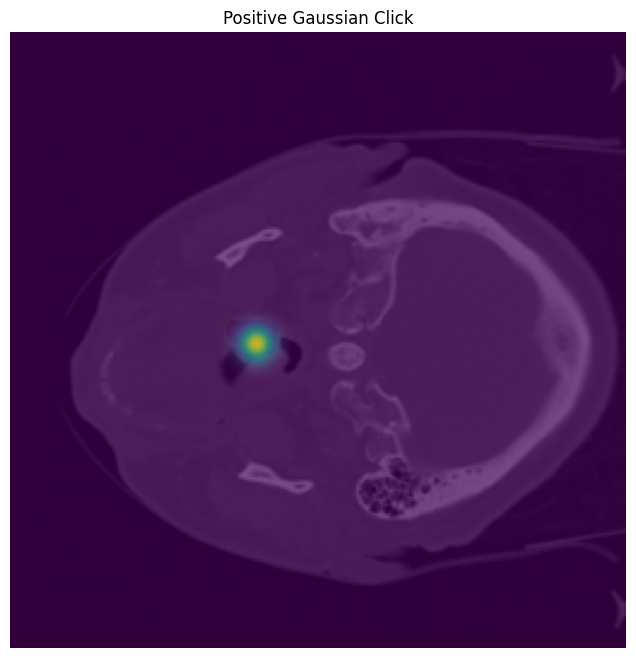

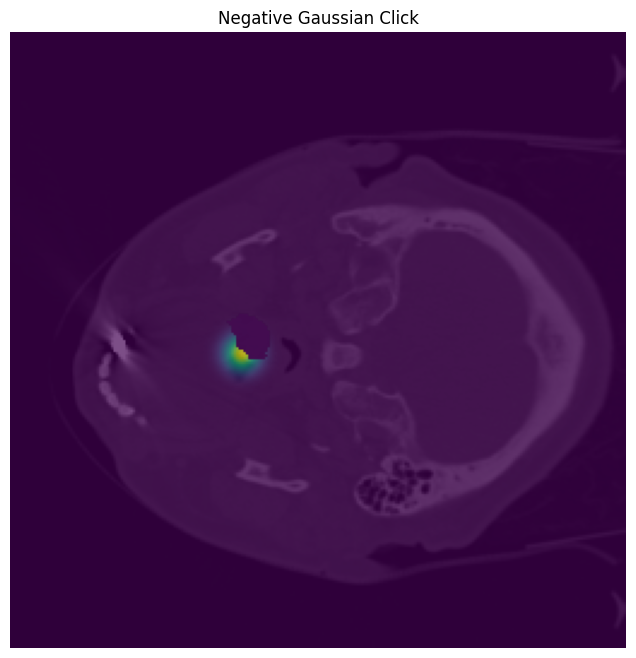

In [25]:
visualize_click_slice(
    image=image,
    mask=mask,
    click_map=positive_click,
    title="Positive Gaussian Click"
)


visualize_click_slice(
    image=image,
    mask=mask,
    click_map=negative_click,
    title="Negative Gaussian Click"
)

In [26]:
import torch
from torch.utils.data import Dataset
class HNCDataset(Dataset):

    def __init__(self,
                 metadata_csv,
                 split):

        self.df = pd.read_csv(metadata_csv)

        self.df = self.df[
            self.df["split"] == split
        ].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            row = self.df.iloc[idx]

            image = nib.load(
                row["image_path"]
            ).get_fdata()

            mask = nib.load(
                row["mask_path"]
            ).get_fdata()

            # -------------------------
            # intensity normalization
            # -------------------------

            image = image.astype(np.float32)

            image = (
                image - image.mean()
            ) / (
                image.std() + 1e-8
            )

            # -------------------------
            # prompt generation
            # -------------------------

            bbox_info = generate_2d_bbox(mask)

            prompt = create_prompt_volume(
                image.shape,
                bbox_info["slice_idx"],
                bbox_info["bbox"],
                radius=3
            )

            # positive and negaitive click
            positive_click = create_positive_click_volume(
              mask)

            negative_click = create_negative_click_volume(
              mask)

            # -------------------------
            # convert to channels-first
            # -------------------------

            image = np.transpose(
                image,
                (2, 0, 1)
            )

            prompt = np.transpose(
                prompt,
                (2, 0, 1)
            )

            mask = np.transpose(
                mask,
                (2, 0, 1)
            )
            positive_click = np.transpose(
              positive_click,
              (2,0,1))

            negative_click = np.transpose(
              negative_click,
              (2,0,1))

            image,mask,prompt,positive_click,negative_click = extract_foreground_patch(
              image,
              mask,
              prompt,
              positive_click,
              negative_click,
              patch_size=(96,96,96))


            input_tensor = np.stack(
                [image, prompt,positive_click,negative_click],
                axis=0
            )


            return {
                "image": torch.tensor(
                    input_tensor,
                    dtype=torch.float32
                ),

                "mask": torch.tensor(
                    mask,
                    dtype=torch.float32
                )
            }
        except Exception as e:
            print(f"Error processing index {idx}: {e}")
            print(f"Problematic row data: {self.df.iloc[idx]}")
            raise # Re-raise the exception after printing for full traceback

In [27]:
def extract_foreground_patch(
    image,
    mask,
    prompt,
    positive_click,
    negative_click,
    patch_size=(96,96,96)
):
    tumor_voxels = np.argwhere(mask > 0)

    if len(tumor_voxels) == 0:
        raise ValueError("Empty mask found")

    center_idx = np.random.randint(len(tumor_voxels))
    cz, cy, cx = tumor_voxels[center_idx]

    hz, hy, hx = [p // 2 for p in patch_size]

    image = np.pad(
        image,
        ((hz,hz),(hy,hy),(hx,hx)),
        mode="constant"
    )

    mask = np.pad(
        mask,
        ((hz,hz),(hy,hy),(hx,hx)),
        mode="constant"
    )

    prompt = np.pad(
        prompt,
        ((hz,hz),(hy,hy),(hx,hx)),
        mode="constant"
    )
    positive_click = np.pad(
      positive_click,
      ((hz,hz),(hy,hy),(hx,hx)),
      mode="constant"
    )

    negative_click = np.pad(
      negative_click,
      ((hz,hz),(hy,hy),(hx,hx)),
      mode="constant"
    )

    cz += hz
    cy += hy
    cx += hx

    image_patch = image[
        cz-hz:cz+hz,
        cy-hy:cy+hy,
        cx-hx:cx+hx
    ]

    mask_patch = mask[
        cz-hz:cz+hz,
        cy-hy:cy+hy,
        cx-hx:cx+hx
    ]

    prompt_patch = prompt[
        cz-hz:cz+hz,
        cy-hy:cy+hy,
        cx-hx:cx+hx
    ]
    positive_click_patch = positive_click[
      cz-hz:cz+hz,
      cy-hy:cy+hy,
      cx-hx:cx+hx
    ]

    negative_click_patch = negative_click[
      cz-hz:cz+hz,
      cy-hy:cy+hy,
      cx-hx:cx+hx
    ]

    return (
    image_patch,
    mask_patch,
    prompt_patch,
    positive_click_patch,
    negative_click_patch
    )

In [28]:
train_ds = HNCDataset(
    metadata_csv=metadata_path,
    split="train"
)

sample = train_ds[0]

print(sample["image"].shape)
print(sample["mask"].shape)

torch.Size([4, 96, 96, 96])
torch.Size([96, 96, 96])


In [29]:
sample = train_ds[0]

print(
    sample["image"][0].shape
)  # CT

print(
    sample["image"][1].shape
)  # Prompt

print(
    sample["image"][2].shape
)  # Positive click

print(
    sample["image"][3].shape
)  # Negative click

torch.Size([96, 96, 96])
torch.Size([96, 96, 96])
torch.Size([96, 96, 96])
torch.Size([96, 96, 96])


In [30]:
sample = train_ds[0]

ct = sample["image"][0].numpy()
prompt = sample["image"][1].numpy()
pos = sample["image"][2].numpy()
neg = sample["image"][3].numpy()
mask = sample["mask"].numpy()

In [31]:
prompt = sample["image"][1].numpy()

print(np.where(prompt.sum(axis=(1,2)) > 0)[0])

[45 46 47 48 49 50 51]


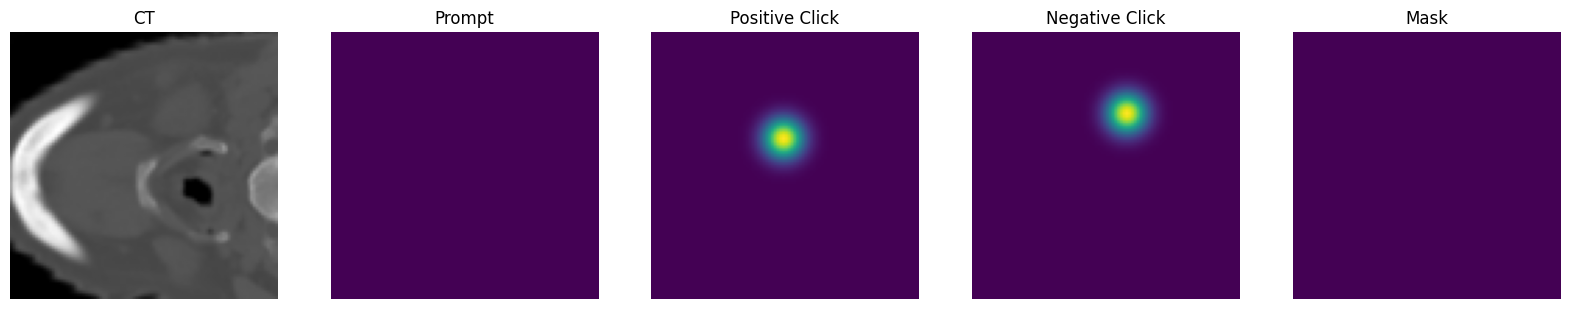

In [32]:
z = 36

plt.figure(figsize=(20,5))

plt.subplot(1,5,1)
plt.imshow(ct[z], cmap="gray")
plt.title("CT")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(prompt[z])
plt.title("Prompt")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(pos[z])
plt.title("Positive Click")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(neg[z])
plt.title("Negative Click")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(mask[z])
plt.title("Mask")
plt.axis("off")

plt.show()

In [33]:
print(
    (pos * mask).max()
)
print(
    (neg * mask).sum()
)

1.0
0.0


In [34]:
train_dataset = HNCDataset(
    metadata_csv=metadata_path,
    split="train"
)

sample = train_dataset[0]

print(
    "Input:",
    sample["image"].shape
)

print(
    "Mask:",
    sample["mask"].shape
)

Input: torch.Size([4, 96, 96, 96])
Mask: torch.Size([96, 96, 96])


In [35]:
CHECKPOINT_DIR = "/content/drive/MyDrive/MIRS-Net/checkpoints"
# checkpoint = torch.load(
#     os.path.join(
#         CHECKPOINT_DIR,
#         "best_model.pth"
#     ),
#     map_location="cpu"
# )

# for key in checkpoint.keys():

#     if "patch" in key.lower():
#         print(key)
# for key in checkpoint.keys():

#     if "proj" in key.lower():
#         print(key)

In [36]:
# checkpoint = torch.load(
#     os.path.join(
#         CHECKPOINT_DIR,
#         "best_model.pth"
#     ),
#     map_location="cpu"
# )

# print(
#     checkpoint[
#         "swinViT.patch_embed.proj.weight"
#     ].shape
# )


In [37]:
from monai.networks.nets import SwinUNETR

device = torch.device("cuda")

model = SwinUNETR(
    in_channels=4,
    out_channels=2,
    feature_size=48,
    patch_size=2,
    use_checkpoint=True
).to(device)

In [38]:
# checkpoint = torch.load(
#     os.path.join(
#         CHECKPOINT_DIR,
#         "best_model.pth"
#     ),
#     map_location="cpu"
# )

In [39]:
# old_weight = checkpoint[
#     "swinViT.patch_embed.proj.weight"
# ]

# print(old_weight.shape)

In [40]:
# new_weight = torch.zeros(
#     (48,4,2,2,2),
#     dtype=old_weight.dtype
# )

# # CT
# new_weight[:,0] = old_weight[:,0]

# # Prompt
# new_weight[:,1] = old_weight[:,1]

# # Positive Click
# new_weight[:,2] = old_weight[:,1]

# # Negative Click
# new_weight[:,3] = old_weight[:,1]

In [41]:
# checkpoint[
#     "swinViT.patch_embed.proj.weight"
# ] = new_weight


In [42]:
# for key, value in checkpoint.items():

#     if value.ndim >= 2:

#         if value.shape[1] == 2:

#             print(
#                 key,
#                 value.shape
#             )

In [43]:
# def expand_input_channels(weight):

#     out_ch = weight.shape[0]
#     kz = weight.shape[2]
#     ky = weight.shape[3]
#     kx = weight.shape[4]

#     new_weight = torch.zeros(
#         (out_ch, 4, kz, ky, kx),
#         dtype=weight.dtype
#     )


#     new_weight[:, 0] = weight[:, 0]


#     new_weight[:, 1] = weight[:, 1]


#     new_weight[:, 2] = weight[:, 1]


#     new_weight[:, 3] = weight[:, 1]

#     return new_weight

In [44]:
# layers_to_expand = [
#     "swinViT.patch_embed.proj.weight",
#     "encoder1.layer.conv1.conv.weight",
#     "encoder1.layer.conv3.conv.weight"
# ]

# for layer_name in layers_to_expand:

#     checkpoint[layer_name] = expand_input_channels(
#         checkpoint[layer_name]
#     )

In [45]:
# for layer_name in layers_to_expand:

#     print(
#         layer_name,
#         checkpoint[layer_name].shape
#     )

In [46]:
# missing, unexpected = model.load_state_dict(
#     checkpoint,
#     strict=False
# )

# print("Missing:", missing)
# print("Unexpected:", unexpected)

In [47]:
# result = model.load_state_dict(
#     checkpoint,
#     strict=False
# )

# print(result)

In [48]:
# torch.save(
#     model.state_dict(),
#     os.path.join(
#         CHECKPOINT_DIR,
#         "stage2_initialized.pth"
#     )
# )

# print("Stage 2 initialization saved")


In [49]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [50]:
batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["mask"].shape)

torch.Size([2, 4, 96, 96, 96])
torch.Size([2, 96, 96, 96])


In [51]:
from monai.networks.nets import SwinUNETR

device = torch.device("cuda")

model = SwinUNETR(
    in_channels=4,
    out_channels=2,
    feature_size=48,
    patch_size=2,
    use_checkpoint=True
).to(device)

model.load_state_dict(
    torch.load(
        os.path.join(
            CHECKPOINT_DIR,
            "stage2_initialized.pth"
        ),
        map_location=device
    )
)

print("Stage 2 model loaded successfully")

Stage 2 model loaded successfully


In [52]:
batch = next(iter(train_loader))

images = batch["image"].to(device)

with torch.no_grad():

    outputs = model(images)

print(outputs.shape)

torch.Size([2, 2, 96, 96, 96])


In [53]:
x = torch.randn(1, 4, 96, 96, 96).to(device)

y = model(x)

print(y.shape)

torch.Size([1, 2, 96, 96, 96])


In [54]:
batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["mask"].shape)

print(batch["mask"].dtype)

print(torch.unique(batch["mask"]))

torch.Size([2, 4, 96, 96, 96])
torch.Size([2, 96, 96, 96])
torch.float32
tensor([0., 1.])


In [55]:
from monai.losses import DiceCELoss

loss_fn = DiceCELoss(
    to_onehot_y=True,
    softmax=True
)

In [56]:
device = "cuda"

model = model.to(device)

batch = next(iter(train_loader))

images = batch["image"].to(device)

masks = batch["mask"].long().to(device)

outputs = model(images)

loss = loss_fn(
    outputs,
    masks.unsqueeze(1)
)

print(loss.item())

0.35266274213790894


In [57]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"{total_params:,}")

62,191,892


In [58]:
val_dataset = HNCDataset(
    metadata_csv=metadata_path,
    split="val"
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [59]:
batch = next(iter(val_loader))

print(batch["image"].shape)
print(batch["mask"].shape)

torch.Size([1, 4, 96, 96, 96])
torch.Size([1, 96, 96, 96])


In [60]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-5
)

In [61]:
from monai.metrics import DiceMetric

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

In [62]:
from monai.transforms import AsDiscrete

post_pred = AsDiscrete(
    argmax=True,
    to_onehot=2
)

post_label = AsDiscrete(
    to_onehot=2
)

In [63]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    loss_fn,
    device
):

    model.train()

    epoch_loss = 0

    for batch in loader:

        images = batch["image"].to(device)

        masks = batch["mask"].long().to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(
            outputs,
            masks.unsqueeze(1)
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [64]:
def validate(
    model,
    loader,
    loss_fn,
    device
):

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for batch in loader:

            images = batch["image"].to(device)

            masks = batch["mask"].long().to(device)

            outputs = model(images)

            loss = loss_fn(
                outputs,
                masks.unsqueeze(1)
            )

            val_loss += loss.item()

    return val_loss / len(loader)

In [65]:
import torch

print(torch.cuda.is_available())

print(torch.cuda.get_device_name(0))

True
Tesla T4


In [66]:
device = torch.device("cuda")

model = model.to(device)

batch = next(iter(train_loader))

images = batch["image"].to(device)
masks = batch["mask"].long().to(device)

print("Model:", next(model.parameters()).device)
print("Images:", images.device)

outputs = model(images)

print("Outputs:", outputs.device)

loss = loss_fn(
    outputs,
    masks.unsqueeze(1)
)

print("Loss:", loss.item())

optimizer.zero_grad()

loss.backward()

optimizer.step()

print("Backward pass successful")

print(
    f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

print(
    f"Reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB"
)

Model: cuda:0
Images: cuda:0
Outputs: cuda:0
Loss: 0.3598663806915283
Backward pass successful
Allocated: 3.64 GB
Reserved: 13.66 GB


In [67]:
best_val_loss = float("inf")

num_epochs = 20

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        loss_fn,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        loss_fn,
        device
    )
    torch.save(
      model.state_dict(),
      os.path.join(
        CHECKPOINT_DIR,
        "latest_stage2_model.pth"
      )
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
         model.state_dict(),
         os.path.join(
         CHECKPOINT_DIR,
         "best_stage2_model.pth"
         )
        )

        print(
            f"New best stage2 model saved! "
            f"Val Loss: {val_loss:.4f}"
        )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

New best stage2 model saved! Val Loss: 0.3141
Epoch 1/20 | Train Loss: 0.2919 | Val Loss: 0.3141
Epoch 2/20 | Train Loss: 0.2715 | Val Loss: 0.3193
New best stage2 model saved! Val Loss: 0.3140
Epoch 3/20 | Train Loss: 0.2590 | Val Loss: 0.3140
New best stage2 model saved! Val Loss: 0.2919
Epoch 4/20 | Train Loss: 0.2419 | Val Loss: 0.2919
Epoch 5/20 | Train Loss: 0.2371 | Val Loss: 0.2922
New best stage2 model saved! Val Loss: 0.2850
Epoch 6/20 | Train Loss: 0.2286 | Val Loss: 0.2850
Epoch 7/20 | Train Loss: 0.2138 | Val Loss: 0.2884
New best stage2 model saved! Val Loss: 0.2635
Epoch 8/20 | Train Loss: 0.2101 | Val Loss: 0.2635
Epoch 9/20 | Train Loss: 0.2072 | Val Loss: 0.2714
Epoch 10/20 | Train Loss: 0.2022 | Val Loss: 0.2785
Epoch 11/20 | Train Loss: 0.1945 | Val Loss: 0.2646
New best stage2 model saved! Val Loss: 0.2516
Epoch 12/20 | Train Loss: 0.1764 | Val Loss: 0.2516
New best stage2 model saved! Val Loss: 0.2408
Epoch 13/20 | Train Loss: 0.1824 | Val Loss: 0.2408
Epoch 14/20

In [68]:
import torch
device = torch.device("cuda")

model= SwinUNETR(
    in_channels=4,
    out_channels=2,
    feature_size=48,
    patch_size=2,
    use_checkpoint=True
).to(device)


model.load_state_dict(
    torch.load(
        os.path.join(
            CHECKPOINT_DIR,
            "best_stage2_model.pth"
        ),
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully")

Best model loaded successfully


In [69]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.data import decollate_batch

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

post_pred = AsDiscrete(
    argmax=True,
    to_onehot=2
)

post_label = AsDiscrete(
    to_onehot=2
)

In [70]:
def evaluate_dice(
    model,
    loader,
    device
):

    model.eval()

    dice_metric.reset()

    with torch.no_grad():

        for batch in loader:

            images = batch["image"].to(device)

            masks = batch["mask"].long().to(device)

            outputs = model(images)

            outputs = [
                post_pred(i)
                for i in decollate_batch(outputs)
            ]

            masks = [
                post_label(i)
                for i in decollate_batch(
                    masks.unsqueeze(1)
                )
            ]

            dice_metric(
                y_pred=outputs,
                y=masks
            )

    mean_dice = dice_metric.aggregate().item()

    dice_metric.reset()

    return mean_dice


In [71]:
val_dice = evaluate_dice(
    model,
    val_loader,
    device
)

print(
    f"Validation Dice: {val_dice:.4f}"
)

Validation Dice: 0.6712


In [72]:
test_dataset = HNCDataset(
    metadata_csv=metadata_path,
    split="test"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

In [73]:
test_dice = evaluate_dice(
    model,
    test_loader,
    device
)

print(
    f"Test Dice: {test_dice:.4f}"
)

Test Dice: 0.6964
